<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/face_kp_detection_vgg16_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torchvision
import torch.nn as nn
import torch
import torch.nn.functional as F
from torchvision import transforms, models, datasets
from torchsummary import summary
import numpy as np, pandas as pd, os, glob, cv2
from glob import glob
from torch.utils.data import TensorDataset,DataLoader,Dataset
from copy import deepcopy
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import cluster
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
!git clone https://github.com/udacity/P1_Facial_Keypoints.git

fatal: destination path 'P1_Facial_Keypoints' already exists and is not an empty directory.


In [ ]:
!cd P1_Facial_Keypoints
!pwd
img_dir = '/content/P1_Facial_Keypoints/data/training/'

/content


In [ ]:
class FacesData(Dataset):
    def __init__(self,df):
        super(FacesData).__init__()
        self.df = df
        self.normalize = transforms.Normalize(
                                mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
    def __len__(self):
        return len(self.df)

    def __getitem__(self,ix):
        img_path = img_dir+self.df.iloc[ix,0]
        img = cv2.imread(img_path)/255.

        kp = deepcopy(self.df.iloc[ix,1:])
        kp_x = (np.array(kp[0::2])/float(img.shape[1])).tolist()
        kp_y = (np.array(kp[1::2])/float(img.shape[0])).tolist()
        kp2 = kp_x+kp_y
        kp2 = torch.tensor(kp2).to(device)
        img = self.preprocess(img)
        return img.to(device), kp2.to(device)

    def preprocess(self, img):
        img = cv2.resize(img,(224,224))
        img = torch.tensor(img).permute(2,0,1)
        img = self.normalize(img).float()
        return img

    def load_img(self, ix):
        img_path = img_dir + self.df.iloc[ix,0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)/255.0
        img = cv2.resize(img, (224,224))
        return img

In [ ]:
data = pd.read_csv('/content/P1_Facial_Keypoints/data/test_frames_keypoints.csv')
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size=0.2,random_state=101)
#print(df.head())
train_dataset = FacesData(train.reset_index(drop=True))
test_dataset = FacesData(test.reset_index(drop=True))

print(f'Total Dataset Length: {len(data)}')
print(f'Train Dataset Length: {len(train)}')
print(f'Test Dataset Length: {len(test)}')

train_dl = DataLoader(train_dataset,batch_size = 32, shuffle = True)
test_dl = DataLoader(train_dataset,batch_size = 32, shuffle = True)

Total Dataset Length: 770
Train Dataset Length: 616
Test Dataset Length: 154


In [ ]:
def get_model():
    model = models.vgg16(pretrained=True)
    for params in model.parameters():
        params.requires_grad = False

    model.avgpool = nn.Sequential(
                            nn.Conv2d(512,512,3),
                            nn.MaxPool2d(2),
                            nn.Flatten()
                        )

    model.classifier = nn.Sequential(
                            nn.Linear(2048,512),
                            nn.ReLU(),
                            nn.Dropout(0.5),
                            nn.Linear(512,136),
                            nn.Sigmoid()
                        )
    loss_fn = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(),lr = 1e-4)
    return model.to(device), loss_fn, optimizer

In [ ]:
def train_batch(x,y,model,loss_fn,optim):
    model.train()
    optim.zero_grad()
    prediction = model(x)
    batch_loss = loss_fn(prediction,y)
    batch_loss.backward()
    optim.step()
    return batch_loss.item()

In [ ]:
def validate_batch(x, y, model, loss_fn):
    model.eval()
    with torch.no_grad():
        pred = model(x)
    loss = loss_fn(pred, y)
    return loss.item()

In [ ]:
model, loss_fn, optimizer = get_model()
summary(model,input_size=(3,224,224))

epoch_number = 50
train_losses,val_losses = [],[]

for epoch in range(epoch_number):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epoch_number}, LR: {optimizer.param_groups[0]['lr']:.6g}")
    epoch_train_loss, epoch_val_loss = 0, 0
    for ix, batch in enumerate(train_dl):
        x,y = batch
        batch_loss = train_batch(x,y,model,loss_fn,optimizer)
        epoch_train_loss += batch_loss
    train_losses.append(epoch_train_loss/(ix+1))

    for ix, batch in enumerate(test_dl):
        x,y = batch
        val_loss = validate_batch(x,y,model,loss_fn)
        epoch_val_loss += val_loss
    val_losses.append(epoch_val_loss/(ix+1))
    print(f"Train Loss: {epoch_train_loss/(ix+1):.4f} | Val Loss: {epoch_val_loss/(ix+1):.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

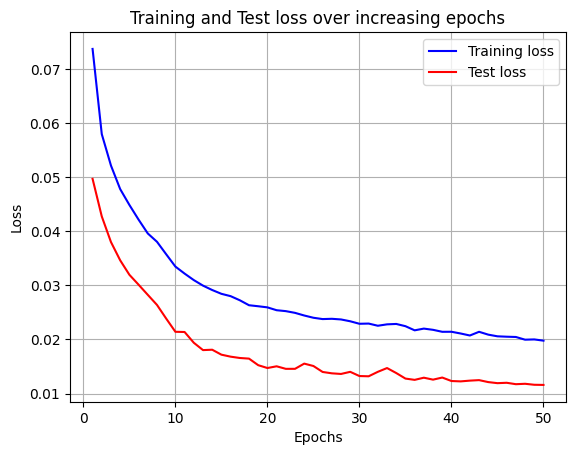

In [ ]:
epochs = np.arange(50)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.plot(epochs, train_losses, 'b-', label='Training loss')
plt.plot(epochs, val_losses, 'r-', label='Test loss')
plt.title('Training and Test loss over increasing epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()

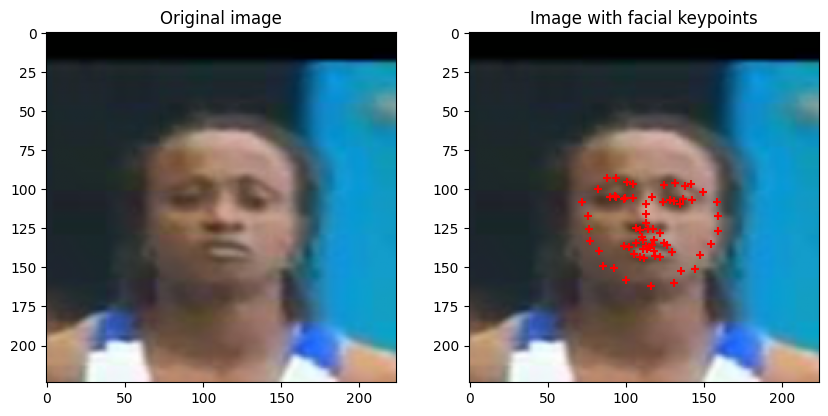

In [ ]:
ix = 152

plt.figure(figsize=(10,10))
plt.subplot(221)
plt.title('Original image')
im = test_dataset.load_img(ix)
plt.imshow(im)
plt.grid(False)
plt.subplot(222)
plt.title('Image with facial keypoints')

x, _ = test_dataset[ix]

plt.imshow(im)

model.eval()
with torch.no_grad():
    kp = model(x.unsqueeze(0)).flatten().detach().cpu()

plt.scatter(kp[:68]*224, kp[68:]*224,marker='+', c='r')
plt.grid(False)
plt.show()

In [ ]:
torch.save(model.state_dict(),'face_key_points.pth')